In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from cuda_cqed.sim import Sim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

## Fast Res Driving

In [2]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wb', 5.35e9*2*pi)
sim.add_param('wc', 7.275e9*2*pi, is_excitation=True)
sim.add_param('sqrtkb', np.sqrt(0.3e6 * 2 * np.pi))
sim.add_param('sqrtkc', np.sqrt(1e6 * 2 * np.pi))
sim.add_param('gbc', 10e6 * 2 * np.pi)
sim.add_param('g3', 50e6 * 2 * np.pi)
sim.add_param('g4', -0.1e6 * 2 * np.pi)
sim.add_param('g6', 0.1e6 * 2 * np.pi)

sim.add_paramsweep('amplC2', 0, 1, 101)
sim.add_paramsweep('wC2', -1.95e9 * 2 * np.pi,  -1.9e9 * 2 * np.pi, 101)
sim.add_param('rampC2', 1e-9)
sim.add_param('startC2', 20e-9)
sim.add_param('stopC2', 200e-9)
sim.add_param('phaseC2', 1)

sim.add_paramsweep('initial_disp', 1, 5, 10)

C2pulse = sim.make_pulse('wC2', 'amplC2', 'phaseC2', 'startC2', 'stopC2', 'rampC2')

sim.add_EOM('s2', C2pulse)
sim.add_EOM('b', '-1j*wb*b - 1j*gbc*c*s2 - (sqrtkb**2/2)*b - 1j*b*g4*abs(b)**2 - 1j*b*g6*abs(b)**4')
sim.add_EOM('c', '-1j*wc*c - 1j*gbc*b*conjugate(s2) - (sqrtkc**2/2)*c', IC_str='initial_disp')
sim.set_solve_type('decimate')

sim.specify_time(pts_per_cycle=20, num_cycles=1500, d_factor=10)

sim.validate()

Recent change to specify_time(), check implementation
Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


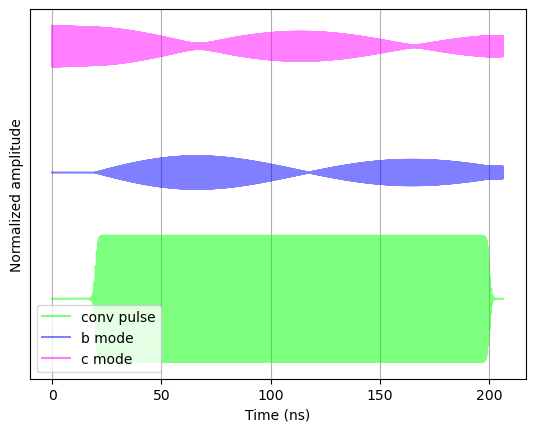

In [3]:
x, t = sim.quick_trace()

scale = 10

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:])+2,color=(0,1,0,0.5),label='conv pulse')
plt.plot(t*1e9, x[2,:]/scale+4,color=(0,0,1,0.5),label='b mode')
plt.plot(t*1e9, x[4,:]/scale+6,color=(1,0,1,0.5),label='c mode')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.yticks([])
plt.grid()
plt.show()

In [4]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|███████████████████████████████████████████████████████████████████████████| 30000/30000 [01:28<00:00, 340.30it/s]


 
...finished GPU solve!


In [5]:
sqrtkb = sim.param_dict_nosweep['sqrtkb']
sqrtkc = sim.param_dict_nosweep['sqrtkc']

bout_I = I[2,:]
bout_Q = I[3,:]

cout_I = Q[4,:]
cout_Q = Q[5,:]

In [6]:
np.shape(bout_I)

(101, 101, 10, 150)

In [7]:
i = 6
measure = cout_I[:,:,i,-1] + 1j*cout_Q[:,:,i,-1]

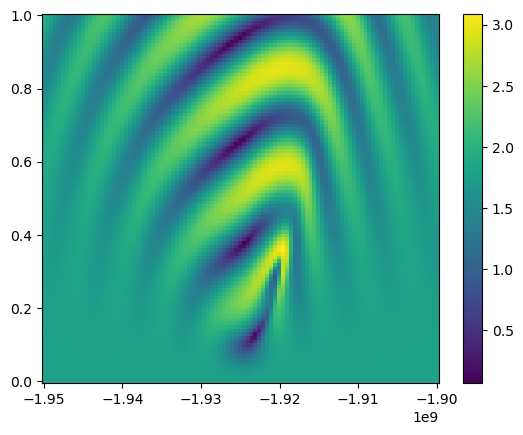

In [213]:
i = 7
measure = cout_I[:,:,i,-1] + 1j*cout_Q[:,:,i,-1]

plt.pcolor(sim.paramsweep_dict['wC2']/(2*np.pi), sim.paramsweep_dict['amplC2'], np.abs(measure))
plt.colorbar()
plt.show()